### Neural Networks

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

rng = np.random.default_rng(42)

In [129]:
train_file_path = "../../input/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
dataset_df = dataset_df.drop('Id', axis=1)
num_df_idx = dataset_df.select_dtypes(include=['float64', 'int64']).columns
cat_df_idx = dataset_df.select_dtypes(exclude=['float64', 'int64']).columns

In [130]:
# numerical features (exclude SalePrice from standardization)
dataset_df['SalePrice'] = np.log1p(dataset_df['SalePrice'])
num_features = [c for c in num_df_idx if c != 'SalePrice']
data_mean = dataset_df[num_features].mean()
data_std = dataset_df[num_features].std()
dataset_df[num_features] = (dataset_df[num_features] - data_mean) / data_std
dataset_df[num_features] = dataset_df[num_features].fillna(0)
# catagorical features
dataset_df = pd.get_dummies(dataset_df, dummy_na=True, dtype=float)
# 确保 SalePrice 在最后一列（get_dummies 会把 dummy 列追加到末尾，SalePrice 不在最后）
cols = [c for c in dataset_df.columns if c != 'SalePrice'] + ['SalePrice']
dataset_df = dataset_df[cols]
print(dataset_df.shape)

(1460, 331)


In [131]:
class MyDataset(Dataset):
    def __init__(self, dataset):
        self.X = dataset[:, :-1]
        self.y = dataset[:, -1:]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [132]:
dataset = torch.tensor(dataset_df.astype('float64').to_numpy(), dtype=torch.float32)
dataset.shape

torch.Size([1460, 331])

In [133]:
def split_dataset(dataset, vali_ratio=0.25):
    vali_indices = rng.random(len(dataset)) < vali_ratio
    return dataset[~vali_indices], dataset[vali_indices]
data_train, data_vali = split_dataset(dataset)

In [134]:
def get_k_fold_dataset(dataset, k=5):
    """
    params:
        dataset: torch.Tensor
        k: int
    return:
        train set, vali set
    """
    n = dataset.shape[0]
    fold_size = n // k
    indices = rng.permutation(n)
    start, end = 0, fold_size
    for _ in range(k):
        vali_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        yield dataset[train_idx], dataset[vali_idx]
        start += fold_size
        end += fold_size

In [183]:
in_features = dataset.shape[1] - 1
def make_net(in_features):
    return nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, 1),
    )
loss = nn.MSELoss()
def log_rmse(net, features, labels):
    # target 已经是 log1p 空间，直接算 RMSE 就等于 RMSLE
    pred = net(features)
    return torch.sqrt(loss(pred, labels))

In [159]:
def train(net, dataset, dataset_vali, epochs, lr, weight_decay, batch_size):
    batch_dataset = MyDataset(dataset)
    dataloader = DataLoader(batch_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(params=net.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_loss = []
    vali_loss = []
    
    for _ in range(epochs):
        net.train()
        for X, y in dataloader:
            # targets are already log1p transformed in the dataframe stage
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            X = dataset[:, :-1]
            y = dataset[:, -1:]
            X_vali = dataset_vali[:, :-1]
            y_vali = dataset_vali[:, -1:]
            train_loss.append(log_rmse(net, X, y).item())
            vali_loss.append(log_rmse(net, X_vali, y_vali).item())

    return train_loss, vali_loss

In [160]:
def k_fold_train(k, dataset, epochs, lr, weight_decay, batch_size):
    """
    params:
        k: int
        other params same as train()
    return:
        avg train loss, avg vali loss
    """
    in_features = dataset.shape[1] - 1
    train_avg, vali_avg = [], []
    for data_train, data_vali in get_k_fold_dataset(dataset, k):
        net = make_net(in_features)
        train_loss, vali_loss = train(net, data_train, data_vali, epochs, lr, weight_decay, batch_size)
        train_avg.append(train_loss)
        vali_avg.append(vali_loss)
    train_avg, vali_avg = np.array(train_avg), np.array(vali_avg)
    train_avg, vali_avg = np.mean(train_avg, axis=0), np.mean(vali_avg, axis=0)
    return train_avg, vali_avg

In [187]:
k, epochs, lr, weight_decay, batch_size = 5, 200, 0.0005, 0.001, 64
train_loss, vali_loss = k_fold_train(k, dataset, epochs, lr, weight_decay, batch_size)
print(f"Baseline RMSLE: train={train_loss[-1]:.4f}, vali={vali_loss[-1]:.4f}, best_vali={np.min(vali_loss):.4f}")

Baseline RMSLE: train=0.0632, vali=0.1506, best_vali=0.1470


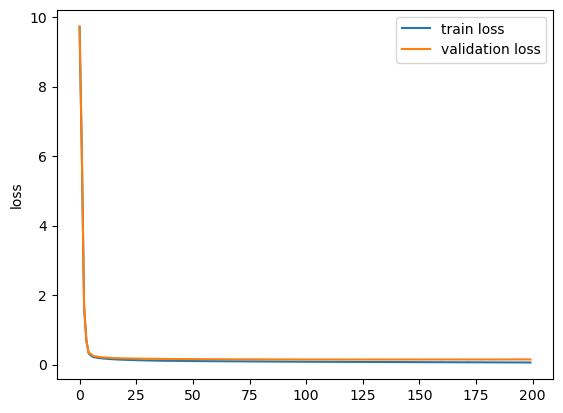

In [188]:
fig, ax = plt.subplots()
x = list(range(len(train_loss)))
ax.plot(x, train_loss, label='train loss')
ax.plot(x, vali_loss, label='validation loss')
ax.set_ylabel('loss')
ax.legend()

In [189]:
print(np.argmin(vali_loss), np.min(vali_loss))

172 0.14703908562660217


In [ ]:
# === Step 1: 搜 lr ===
k, epochs, batch_size = 5, 200, 64
lrs = [5e-4, 1e-3, 3e-3, 5e-3, 1e-2]
print("=== Step 1: 搜索 lr ===")
best_vali, best_lr = float('inf'), None
for lr in lrs:
    _, vl = k_fold_train(k, dataset, epochs, lr, 0, batch_size)
    mv = np.min(vl)
    print(f"  lr={lr} -> best_vali_RMSLE={mv:.4f}")
    if mv < best_vali:
        best_vali, best_lr = mv, lr
print(f"  Best lr={best_lr}, RMSLE={best_vali:.4f}\n")

# === Step 2: 固定最佳 lr，搜 weight_decay ===
weight_decays = [0, 1e-4, 1e-3, 1e-2, 0.1]
print("=== Step 2: 搜索 weight_decay ===")
best_wd = 0
for wd in weight_decays:
    _, vl = k_fold_train(k, dataset, epochs, best_lr, wd, batch_size)
    mv = np.min(vl)
    print(f"  wd={wd} -> best_vali_RMSLE={mv:.4f}")
    if mv < best_vali:
        best_vali, best_wd = mv, wd
print(f"  Best wd={best_wd}, RMSLE={best_vali:.4f}\n")

print(f"=== 最优参数: lr={best_lr}, weight_decay={best_wd}, RMSLE={best_vali:.4f} ===")

=== Step 3: 搜索 dropout ===
  dropout=0 -> best_vali_RMSLE=0.1421
  dropout=0.2 -> best_vali_RMSLE=0.1663
  dropout=0.5 -> best_vali_RMSLE=0.1898
  Best dropout=0, RMSLE=0.1421

=== 最优参数: lr=0.0005, weight_decay=0.001, dropout=0, RMSLE=0.1421 ===
